# Traditional ML Baseline: SVM & Random Forest for Lung CT

This notebook serves as a standalone baseline to compare against Deep Learning methods. It validates whether complex Deep Learning is strictly necessary by testing lighter models.

**Part 1: Binary Classification (Normal vs. Disease)**
- **SVM (Support Vector Machine):** Uses PCA for dimensionality reduction (Efficiency focus).
- **Random Forest:** Uses raw pixels to determine feature importance (Interpretability focus).

**Part 2: Multi-Class Classification (5 Classes)**
- Classifying specific disease types: *Benign, Normal, Adenocarcinoma, Large Cell Carcinoma, Squamous Cell Carcinoma*.

**Visualizations:**
- Decision Boundaries (PCA Projected 2D plots).
- Pixel Importance Heatmaps.
- Confusion Matrices.

**Assumptions:**
- Data is located in `./Dataset/`.

In [1]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Config
DATA_DIR = './Dataset'
IMG_SIZE = (64, 64) # Resize to 64x64 (4096 features) to keep SVM training feasible
SEED = 42

np.random.seed(SEED)

## Part 1: Binary Classification (Normal vs. Disease)

In [2]:
# --- 1. Load Data (Binary) ---
class_names = ['Benign', 'Normal', 'Adenocarcinoma', 'Large_cell_carcinoma', 'Squamous_Cell_Carcinoma']

def load_binary_data(data_dir, img_size):
    print("Scanning dataset for Binary Classification...")
    X = []
    y = []
    files_found = 0
    
    for cls in class_names:
        cls_folder = os.path.join(data_dir, cls)
        if not os.path.exists(cls_folder):
            print(f"Warning: Folder not found {cls_folder}")
            continue
            
        # Label: 0 for Normal, 1 for Disease
        label = 0 if cls == 'Normal' else 1
        
        for img_path in Path(cls_folder).glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif']:
                try:
                    # Open, Convert to Grayscale (L), Resize
                    img = Image.open(img_path).convert('L').resize(img_size)
                    # Flatten: 2D image -> 1D vector
                    img_flat = np.array(img).flatten()
                    X.append(img_flat)
                    y.append(label)
                    files_found += 1
                except Exception as e:
                    pass
                    
    print(f"Loaded {files_found} images. Shape: {np.array(X).shape}")
    return np.array(X), np.array(y)

X, y = load_binary_data(DATA_DIR, IMG_SIZE)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Scanning dataset for Binary Classification...
Loaded 1535 images. Shape: (1535, 4096)
Train shape: (1228, 4096) | Test shape: (307, 4096)


In [3]:
# --- 2. Train SVM (with PCA) ---
print("\n--- Training SVM (Binary) ---")
print("Preprocessing: Scaler -> PCA (0.95 variance) -> SVC")

# SVM Pipeline: Scale features -> Reduce dims (PCA) -> Classifier
svm_pipe = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95, random_state=SEED), # Keep 95% of variance
    SVC(kernel='rbf', C=1.0, probability=True, random_state=SEED)
)

t0 = time.time()
svm_pipe.fit(X_train, y_train)
print(f"SVM Training Time: {time.time()-t0:.2f}s")

y_pred_svm = svm_pipe.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.4f}")


--- Training SVM (Binary) ---
Preprocessing: Scaler -> PCA (0.95 variance) -> SVC
SVM Training Time: 1.89s
SVM Accuracy: 0.9544


In [4]:
# --- 3. Train Random Forest (Raw Pixels) ---
print("\n--- Training Random Forest (Binary) ---")
print("Preprocessing: Raw Pixels -> Random Forest (100 Trees)")

# RF handles raw high-dim features well and gives us feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

t0 = time.time()
rf_model.fit(X_train, y_train)
print(f"RF Training Time: {time.time()-t0:.2f}s")

y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"RF Accuracy: {acc_rf:.4f}")


--- Training Random Forest (Binary) ---
Preprocessing: Raw Pixels -> Random Forest (100 Trees)
RF Training Time: 0.45s
RF Accuracy: 0.9805


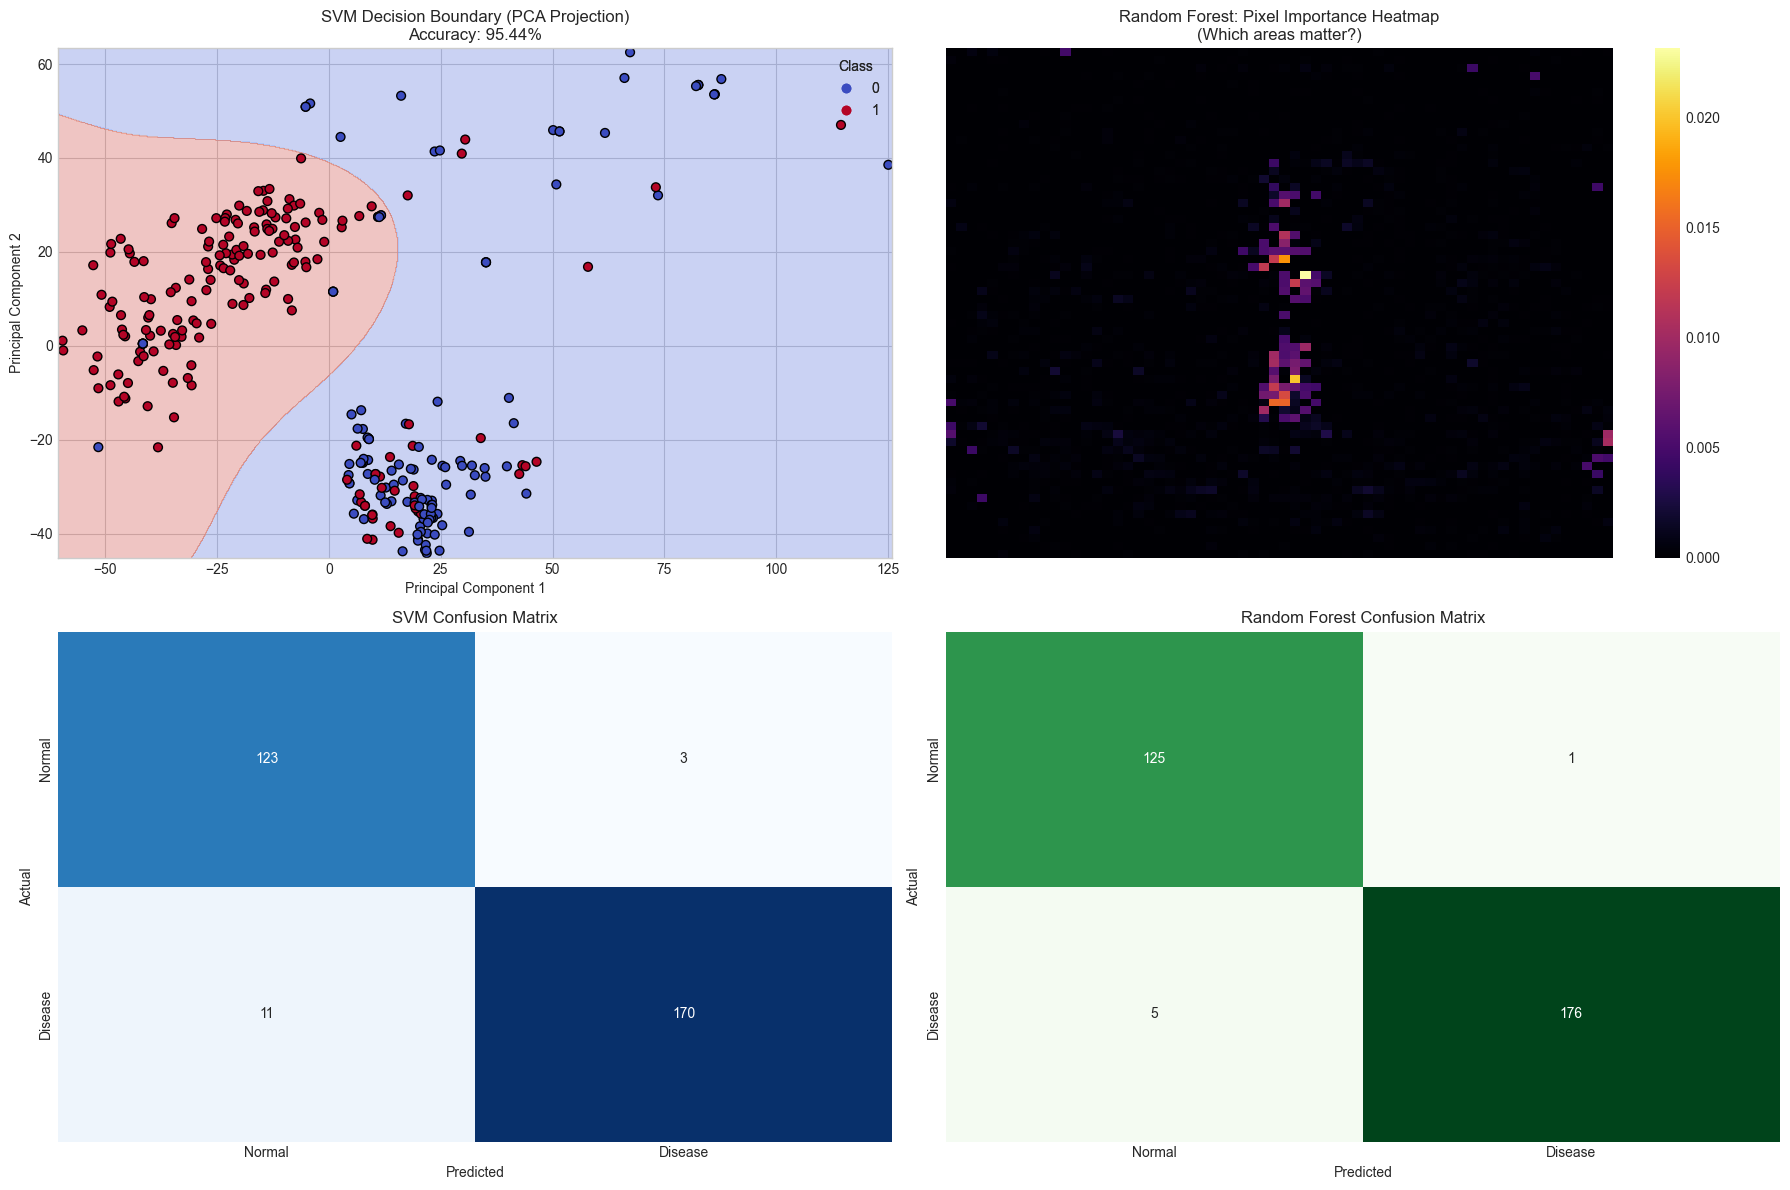

In [5]:
# --- 4. Visualizations (Binary) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 12))

# --- Viz 1: SVM Decision Boundary (PCA Projection) ---
# To visualize the boundary, we need to train a 2D SVM just for the plot
ax1 = plt.subplot(2, 2, 1)

# 1. Get PCA transformation of data
pca_2d = PCA(n_components=2)
X_train_pca2 = pca_2d.fit_transform(StandardScaler().fit_transform(X_train))
X_test_pca2 = pca_2d.transform(StandardScaler().fit_transform(X_test))

# 2. Train simple SVM on 2D data for visualization
svm_2d = SVC(kernel='rbf', C=1.0)
svm_2d.fit(X_train_pca2, y_train)

# 3. Create meshgrid
x_min, x_max = X_test_pca2[:, 0].min() - 1, X_test_pca2[:, 0].max() + 1
y_min, y_max = X_test_pca2[:, 1].min() - 1, X_test_pca2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plot
ax1.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = ax1.scatter(X_test_pca2[:, 0], X_test_pca2[:, 1], c=y_test, s=40, edgecolors='k', cmap=plt.cm.coolwarm)
ax1.set_title(f'SVM Decision Boundary (PCA Projection)\nAccuracy: {acc_svm:.2%}')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
legend1 = ax1.legend(*scatter.legend_elements(), title="Class")
ax1.add_artist(legend1)


# --- Viz 2: Random Forest Pixel Importance ---
# Reshape importances (4096,) back to image (64, 64)
ax2 = plt.subplot(2, 2, 2)
importances = rf_model.feature_importances_.reshape(IMG_SIZE)
sns.heatmap(importances, cmap='inferno', ax=ax2)
ax2.set_title('Random Forest: Pixel Importance Heatmap\n(Which areas matter?)')
ax2.axis('off')


# --- Viz 3: Confusion Matrices ---
ax3 = plt.subplot(2, 2, 3)
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('SVM Confusion Matrix')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_xticklabels(['Normal', 'Disease'])
ax3.set_yticklabels(['Normal', 'Disease'])

ax4 = plt.subplot(2, 2, 4)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax4, cbar=False)
ax4.set_title('Random Forest Confusion Matrix')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_xticklabels(['Normal', 'Disease'])
ax4.set_yticklabels(['Normal', 'Disease'])

plt.tight_layout()
plt.show()

## Part 2: Multi-Class Classification (5 Classes)

We now attempt to classify the specific disease type.

In [6]:
# --- 5. Load Data (Multi-Class) ---
class_map = {
    'Benign': 0,
    'Normal': 1,
    'Adenocarcinoma': 2,
    'Large_cell_carcinoma': 3,
    'Squamous_Cell_Carcinoma': 4
}
inv_map = {v: k for k, v in class_map.items()}

def load_multiclass_data(data_dir, img_size):
    print("Loading Multi-Class Data...")
    X_m = []
    y_m = []
    
    for cls, label_idx in class_map.items():
        cls_folder = os.path.join(data_dir, cls)
        if not os.path.exists(cls_folder):
            continue
            
        for img_path in Path(cls_folder).glob('*'):
            if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.tif']:
                try:
                    img = Image.open(img_path).convert('L').resize(img_size)
                    X_m.append(np.array(img).flatten())
                    y_m.append(label_idx)
                except:
                    pass
    return np.array(X_m), np.array(y_m)

X_multi, y_multi = load_multiclass_data(DATA_DIR, IMG_SIZE)

# Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, stratify=y_multi, random_state=SEED
)
print(f"Multi-class Train: {X_train_m.shape}, Labels: {len(np.unique(y_train_m))}")

Loading Multi-Class Data...
Multi-class Train: (1228, 4096), Labels: 5


In [7]:
# --- 6. Train Multi-Class Models ---

print("Training Multi-Class SVM (One-vs-Rest)...")
svm_multi = make_pipeline(
    StandardScaler(),
    PCA(n_components=0.95, random_state=SEED),
    SVC(kernel='rbf', C=1.0, decision_function_shape='ovr', random_state=SEED)
)
t0 = time.time()
svm_multi.fit(X_train_m, y_train_m)
print(f"SVM Done ({time.time()-t0:.2f}s)")

print("Training Multi-Class Random Forest...")
rf_multi = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
t0 = time.time()
rf_multi.fit(X_train_m, y_train_m)
print(f"RF Done ({time.time()-t0:.2f}s)")

Training Multi-Class SVM (One-vs-Rest)...
SVM Done (1.80s)
Training Multi-Class Random Forest...
RF Done (0.80s)



--- Multi-Class SVM Report ---
                         precision    recall  f1-score   support

                 Benign       0.95      0.83      0.89        24
                 Normal       0.95      0.98      0.97       126
         Adenocarcinoma       0.68      0.84      0.75        68
   Large_cell_carcinoma       0.80      0.65      0.72        37
Squamous_Cell_Carcinoma       0.83      0.67      0.74        52

               accuracy                           0.85       307
              macro avg       0.84      0.80      0.81       307
           weighted avg       0.85      0.85      0.85       307


--- Multi-Class Random Forest Report ---
                         precision    recall  f1-score   support

                 Benign       1.00      0.92      0.96        24
                 Normal       0.97      0.99      0.98       126
         Adenocarcinoma       0.72      0.85      0.78        68
   Large_cell_carcinoma       0.81      0.70      0.75        37
Squamous_Cel

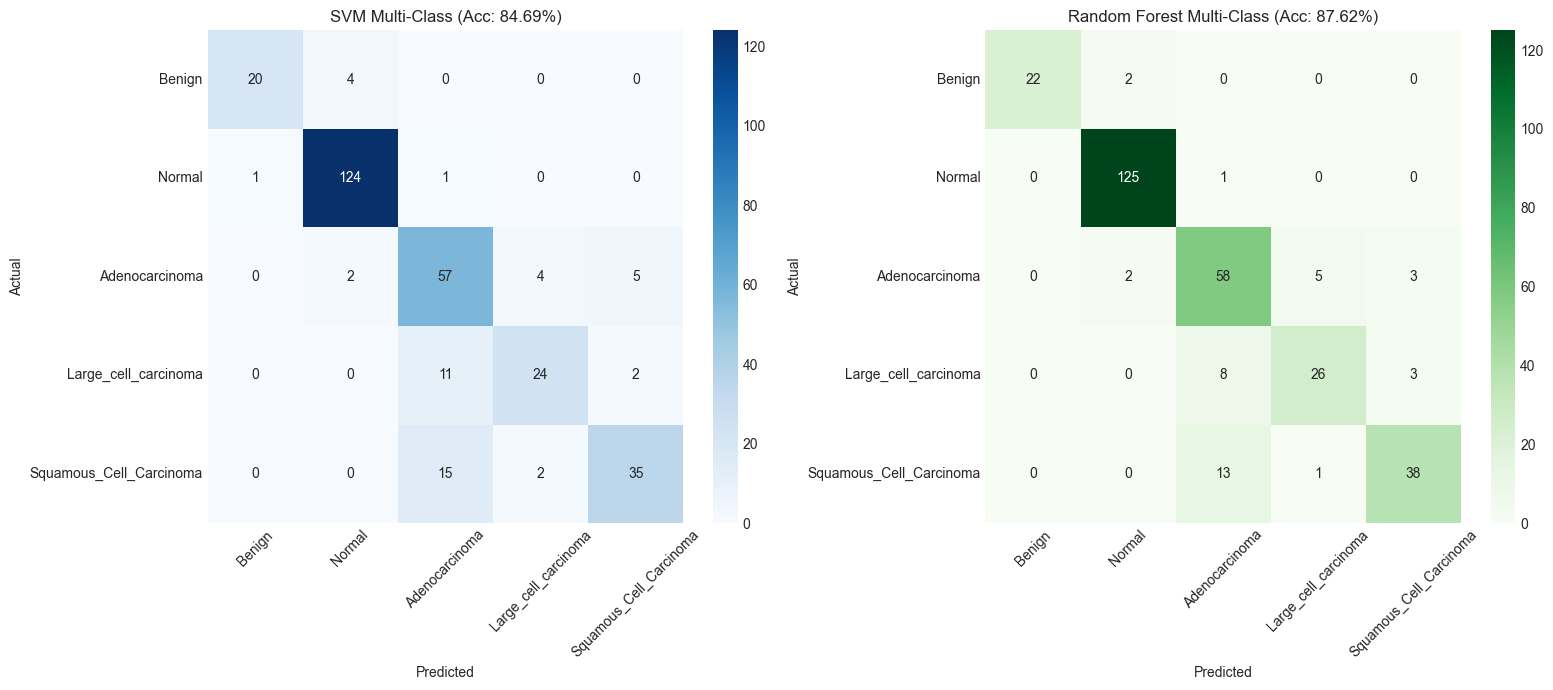

In [8]:
# --- 7. Evaluate Multi-Class ---

# Predictions
y_pred_svm_m = svm_multi.predict(X_test_m)
y_pred_rf_m = rf_multi.predict(X_test_m)

target_names = [inv_map[i] for i in range(5)]

# Print Reports
print("\n--- Multi-Class SVM Report ---")
print(classification_report(y_test_m, y_pred_svm_m, target_names=target_names))

print("\n--- Multi-Class Random Forest Report ---")
print(classification_report(y_test_m, y_pred_rf_m, target_names=target_names))

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# SVM Matrix
sns.heatmap(confusion_matrix(y_test_m, y_pred_svm_m), annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title(f'SVM Multi-Class (Acc: {accuracy_score(y_test_m, y_pred_svm_m):.2%})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# RF Matrix
sns.heatmap(confusion_matrix(y_test_m, y_pred_rf_m), annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title(f'Random Forest Multi-Class (Acc: {accuracy_score(y_test_m, y_pred_rf_m):.2%})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Generating 2D Decision Boundary Plot (this may take a moment)...


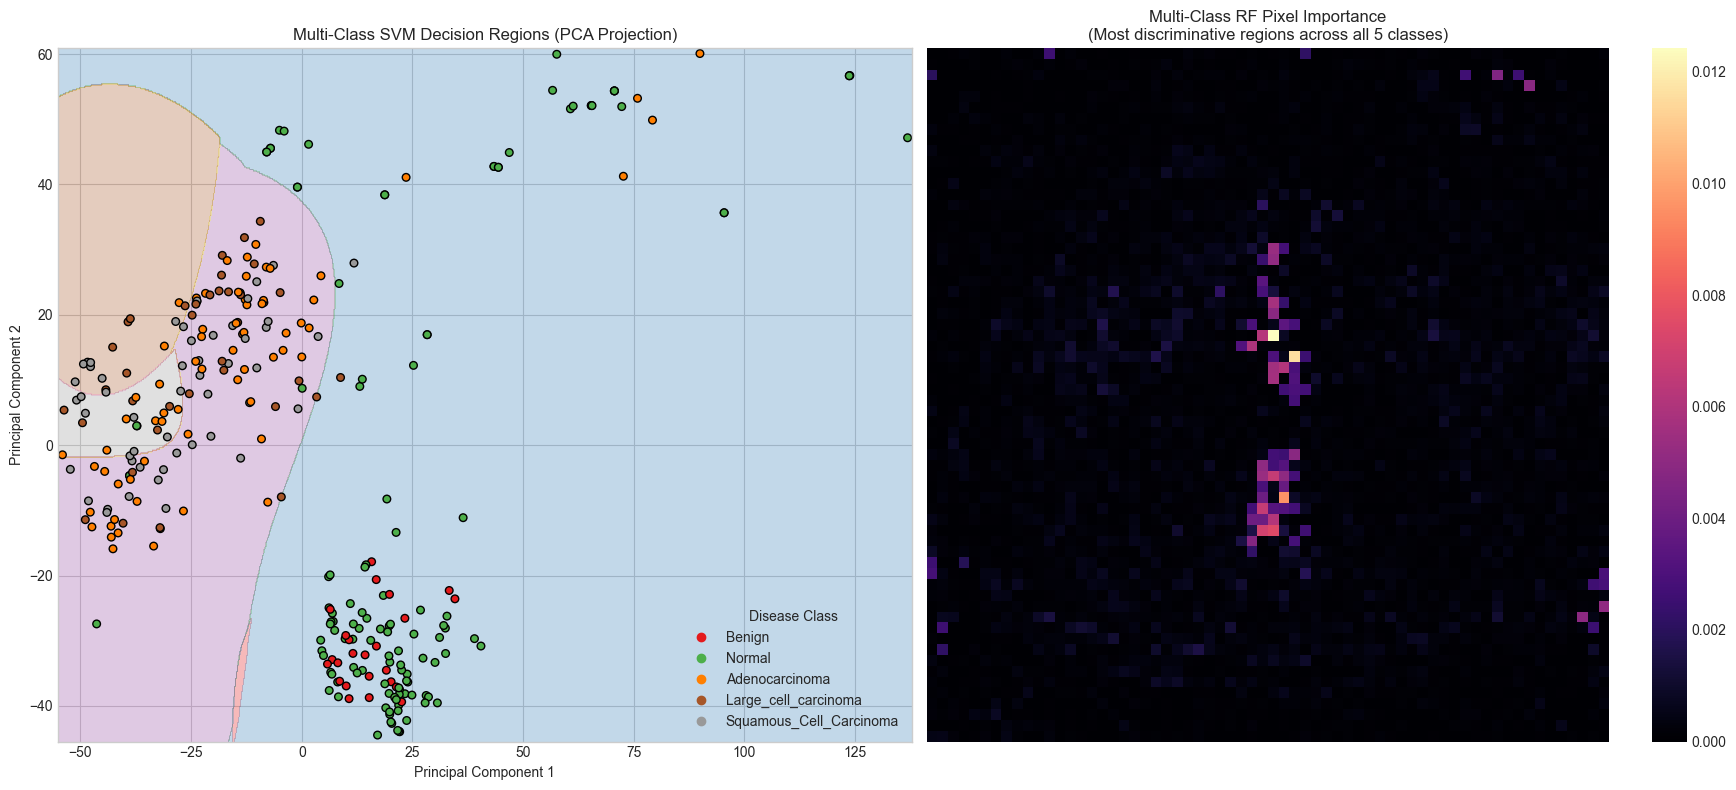

In [9]:
# --- 8. Visualizations (Multi-Class 2D Plots) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(18, 8))

# --- Viz 1: Multi-Class SVM Decision Boundary (PCA Projection) ---
ax1 = plt.subplot(1, 2, 1)

# 1. Project to 2D for visualization
# We strictly use the training set fit to keep data leakage rules intact
pca_2d_m = PCA(n_components=2)
X_train_pca2_m = pca_2d_m.fit_transform(StandardScaler().fit_transform(X_train_m))
X_test_pca2_m = pca_2d_m.transform(StandardScaler().fit_transform(X_test_m))

# 2. Train a proxy 2D model just for the plot boundaries
print("Generating 2D Decision Boundary Plot (this may take a moment)...")
svm_2d_m = SVC(kernel='rbf', C=1.0, decision_function_shape='ovr')
svm_2d_m.fit(X_train_pca2_m, y_train_m)

# 3. Meshgrid for background color
x_min, x_max = X_test_pca2_m[:, 0].min() - 1, X_test_pca2_m[:, 0].max() + 1
y_min, y_max = X_test_pca2_m[:, 1].min() - 1, X_test_pca2_m[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))

# 4. Predict regions
Z = svm_2d_m.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot
# Use a qualitative colormap (Set1) for distinct classes
cmap = plt.cm.Set1
ax1.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)
scatter = ax1.scatter(X_test_pca2_m[:, 0], X_test_pca2_m[:, 1], c=y_test_m, s=30, edgecolors='k', cmap=cmap)

ax1.set_title('Multi-Class SVM Decision Regions (PCA Projection)')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

# Add Legend with actual Class Names
handles, _ = scatter.legend_elements()
ax1.legend(handles, target_names, title="Disease Class", loc="best")


# --- Viz 2: Random Forest Feature Importance (Multi-Class) ---
ax2 = plt.subplot(1, 2, 2)
# Reshape importances (4096,) back to image (64, 64)
importances_m = rf_multi.feature_importances_.reshape(IMG_SIZE)

sns.heatmap(importances_m, cmap='magma', ax=ax2)
ax2.set_title('Multi-Class RF Pixel Importance\n(Most discriminative regions across all 5 classes)')
ax2.axis('off')

plt.tight_layout()
plt.show()